01 - Build a clean and reproducible market data pipeline that loads Treasury and/or SOFR market quotes, converts them into a usable term structure format, and prepares the data for yield curve bootstrapping.

What a is yield curve? 
Treasury securities as risk-free benchmarks
Difference between:
Treasury Bills
Treasury Notes
Treasury Bonds
Why yield curve construction is important

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
from pandas_datareader import data as web

In [5]:
series = {
    "3M": "DGS3MO",
    "6M": "DGS6MO",
    "1Y": "DGS1",
    "2Y": "DGS2",
    "3Y": "DGS3",
    "5Y": "DGS5",
    "7Y": "DGS7",
    "10Y": "DGS10",
    "20Y": "DGS20",
    "30Y": "DGS30"
}

end = datetime.today()
start = end - pd.DateOffset(days=30)

treasury = pd.DataFrame()

for maturity, fred_code in series.items():
    treasury[maturity] = web.DataReader(
        fred_code,
        "fred",
        start,
        end
    )[fred_code]



In [6]:
from pathlib import Path

ROOT = Path.cwd().parent

treasury.to_csv(ROOT / "data/treasury_yields.csv")

In [7]:
latest_curve = treasury.ffill().iloc[-1]

curve = (
    latest_curve
    .rename("Yield")
    .reset_index()
    .rename(columns={"index": "Maturity"})
)

curve

,Maturity,Yield
0,3M,3.87
1,6M,4.02
2,1Y,4.08
3,2Y,4.26
4,3Y,4.31
5,5Y,4.37
6,7Y,4.50
7,10Y,4.63
8,20Y,5.14
9,30Y,5.13


In [8]:
def maturity_to_years(maturity: str) -> float:
    if maturity.endswith("M"):
        return int(maturity[:-1]) / 12
    elif maturity.endswith("Y"):
        return int(maturity[:-1])
    else:
        raise ValueError(f"Invalid maturity format: {maturity}")

curve["Years"] = curve["Maturity"].apply(maturity_to_years)
curve

,Maturity,Yield,Years
0,3M,3.87,0.25
1,6M,4.02,0.50
2,1Y,4.08,1.00
3,2Y,4.26,2.00
4,3Y,4.31,3.00
5,5Y,4.37,5.00
6,7Y,4.50,7.00
7,10Y,4.63,10.00
8,20Y,5.14,20.00
9,30Y,5.13,30.00


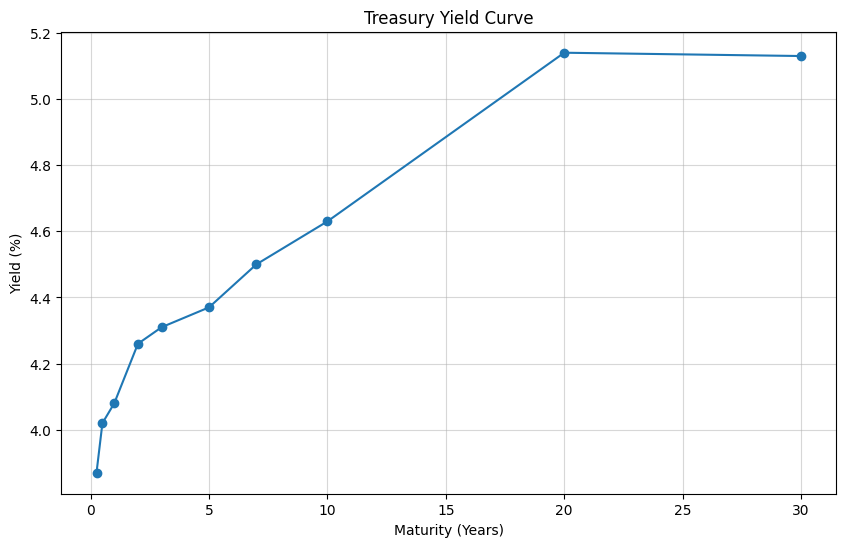

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(curve["Years"], curve["Yield"], marker='o')

plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("Treasury Yield Curve")
plt.grid(alpha = 0.5)


In [10]:
curve["Discount Factor"] = (1 / (1 + curve["Yield"] / 100) ** curve["Years"])
curve

,Maturity,Yield,Years,Discount Factor
0,3M,3.87,0.25,0.990552
1,6M,4.02,0.50,0.980486
2,1Y,4.08,1.00,0.960799
3,2Y,4.26,2.00,0.919951
4,3Y,4.31,3.00,0.881094
5,5Y,4.37,5.00,0.807461
6,7Y,4.50,7.00,0.734828
7,10Y,4.63,10.00,0.635972
8,20Y,5.14,20.00,0.366978
9,30Y,5.13,30.00,0.222946


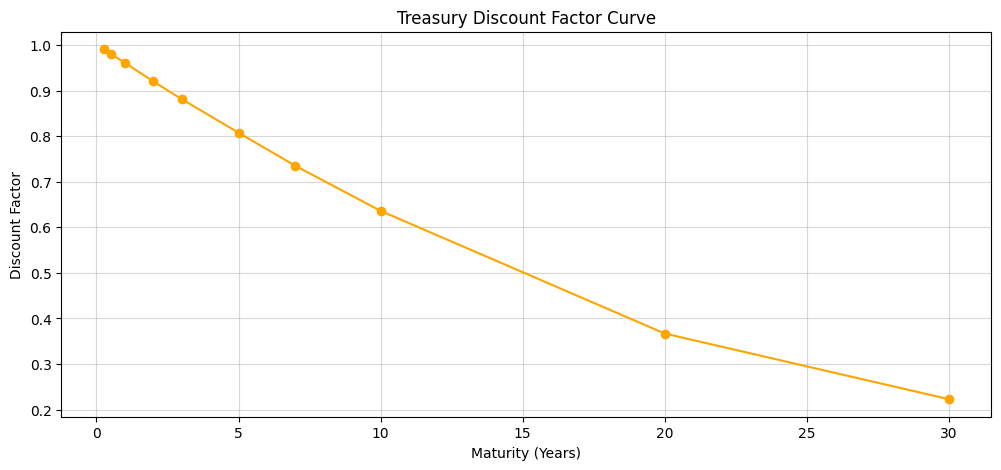

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(curve["Years"], curve["Discount Factor"], marker='o', color='orange')
plt.xlabel("Maturity (Years)")
plt.ylabel("Discount Factor")
plt.title("Treasury Discount Factor Curve")
plt.grid(alpha=0.5)

In [12]:
from pathlib import Path

ROOT = Path.cwd().parent

curve.to_csv(ROOT / "data/clean_treasury_curve.csv", index=False)